# Week 7: TrashNet Error Analysis using EfficientNetB0

## Objective

The objective of this notebook is to perform a detailed error analysis of the fine-tuned EfficientNetB0 model on the TrashNet dataset. Rather than focusing only on overall accuracy, this notebook investigates why the model makes incorrect predictions by analyzing the confusion matrix, classification report, misclassified images, and Grad-CAM visualizations.

## Workflow

- Load the fine-tuned EfficientNetB0 model.
- Evaluate the model on the validation dataset.
- Generate the confusion matrix and classification report.
- Identify the most common confusion pairs.
- Display misclassified images for detailed inspection.
- Perform Grad-CAM analysis on representative misclassified samples.
- Summarize the observations and identify possible improvements.

**Dataset:** TrashNet

**Model:** EfficientNetB0 (Transfer Learning + Fine-Tuning)

**Classes:** Cardboard, Glass, Metal, Paper, Plastic, Trash

# Week 7: TrashNet Error Analysis

## Objective

The objective of this notebook is to analyze the prediction errors made by the EfficientNetB0 model trained on the TrashNet dataset.

Instead of improving the model through training, this notebook focuses on understanding why the model makes mistakes by studying misclassified images.

The analysis includes:

- Identifying the most common confusion pairs
- Displaying misclassified validation images
- Studying prediction confidence
- Performing Grad-CAM visualization
- Understanding whether errors are caused by ambiguous images, poor image quality, incorrect labels, or model limitations.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/data/trashnet"

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

In [4]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [5]:
class_names = validation_dataset.class_names

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
model = load_model(
    "/content/drive/MyDrive/trashnet_feature_extraction.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [7]:
predictions = model.predict(validation_dataset)

predicted_labels = np.argmax(predictions, axis=1)

confidence_scores = np.max(predictions, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step


In [8]:
true_labels = np.concatenate(
    [labels.numpy() for images, labels in validation_dataset]
)

In [9]:
accuracy = np.mean(predicted_labels == true_labels)

print(f"Validation Accuracy: {accuracy*100:.2f}%")

Validation Accuracy: 88.32%


In [10]:
cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

[[  0   0   0   0   0   0]
 [  0   0   0   0   0   0]
 [  0   0   0   0   0   0]
 [  0   0   0   0   0   0]
 [  0  14  10   4 331   9]
 [  2   3   7   8   2 115]]


In [24]:
validation_images = []
true_labels = []
predicted_labels = []
confidence_scores = []

for images, labels in validation_dataset:

    preds = model.predict(images, verbose=0)

    pred_classes = np.argmax(preds, axis=1)

    confidences = np.max(preds, axis=1)

    validation_images.extend(images.numpy())

    true_labels.extend(labels.numpy())

    predicted_labels.extend(pred_classes)

    confidence_scores.extend(confidences)

validation_images = np.array(validation_images)
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)
confidence_scores = np.array(confidence_scores)

print("Validation Images:", validation_images.shape)
print("Labels:", true_labels.shape)

Validation Images: (505, 224, 224, 3)
Labels: (505,)


In [25]:
import pandas as pd

results = pd.DataFrame({
    "True": true_labels,
    "Pred": predicted_labels,
    "Confidence": confidence_scores
})

results["True_Name"] = results["True"].apply(lambda x: class_names[x])
results["Pred_Name"] = results["Pred"].apply(lambda x: class_names[x])

results.head()

,True,Pred,Confidence,True_Name,Pred_Name
0,4,4,0.998998,plastic,plastic
1,4,4,0.982210,plastic,plastic
2,4,4,0.991257,plastic,plastic
3,4,4,0.971906,plastic,plastic
4,4,4,0.999488,plastic,plastic


In [26]:
misclassified = results[
    results["True"] != results["Pred"]
]

print("Total Misclassified Images:", len(misclassified))

Total Misclassified Images: 59


In [27]:
pairs = (
    misclassified.groupby(["True_Name", "Pred_Name"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

pairs

,True_Name,Pred_Name,Count
0,plastic,glass,14
1,plastic,metal,10
3,plastic,trash,9
7,trash,paper,8
6,trash,metal,7
2,plastic,paper,4
5,trash,glass,3
4,trash,cardboard,2
8,trash,plastic,2


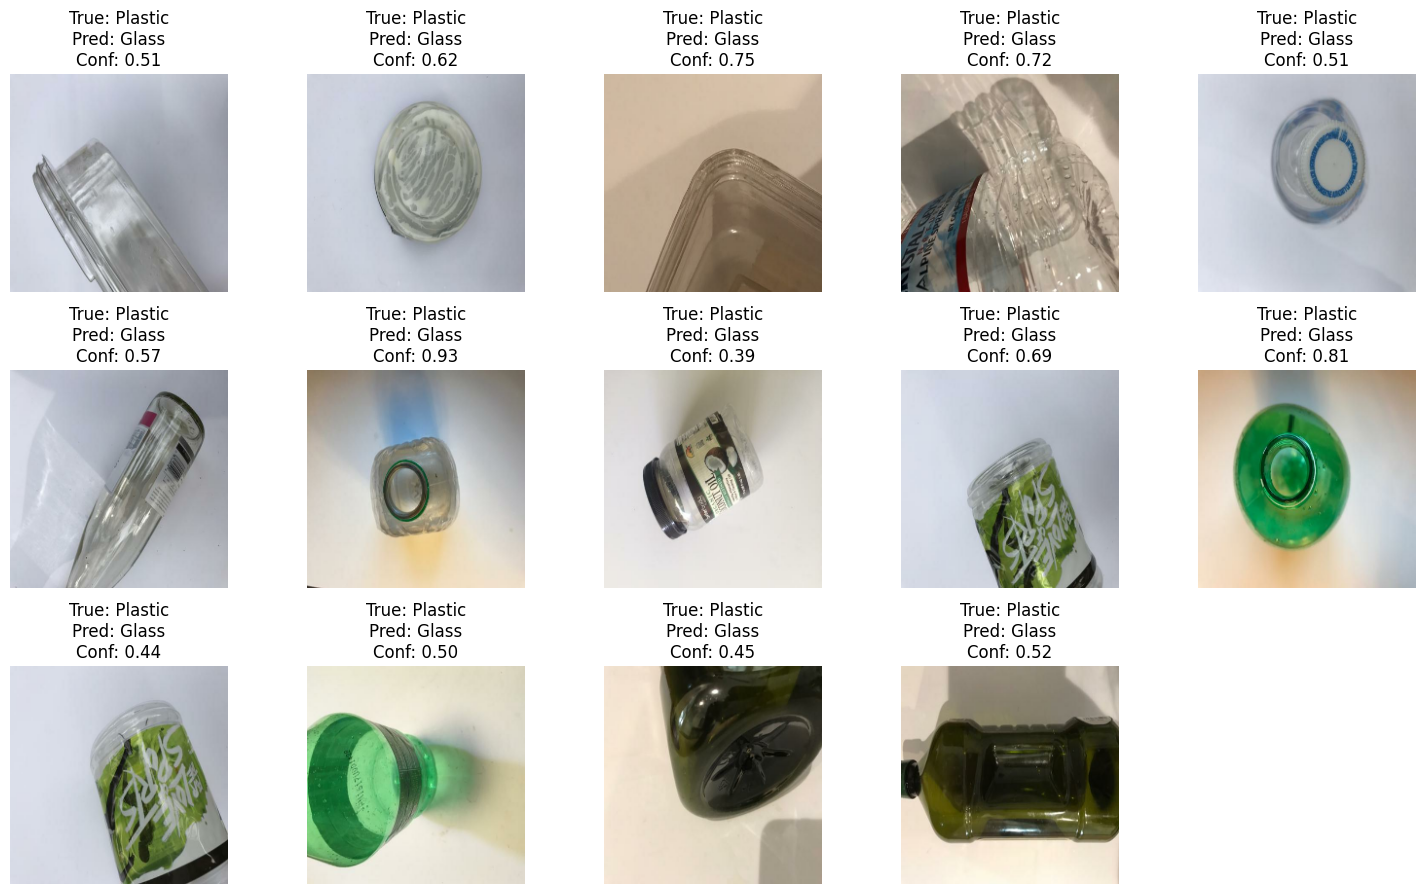

In [28]:
pair = results[
    (results["True_Name"] == "plastic") &
    (results["Pred_Name"] == "glass")
]

plt.figure(figsize=(15,12))

indices = pair.index.tolist()[:20]

for i, idx in enumerate(indices):

    plt.subplot(4,5,i+1)

    plt.imshow(validation_images[idx].astype(np.uint8))

    plt.title(
        f"True: Plastic\n"
        f"Pred: Glass\n"
        f"Conf: {results.loc[idx,'Confidence']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

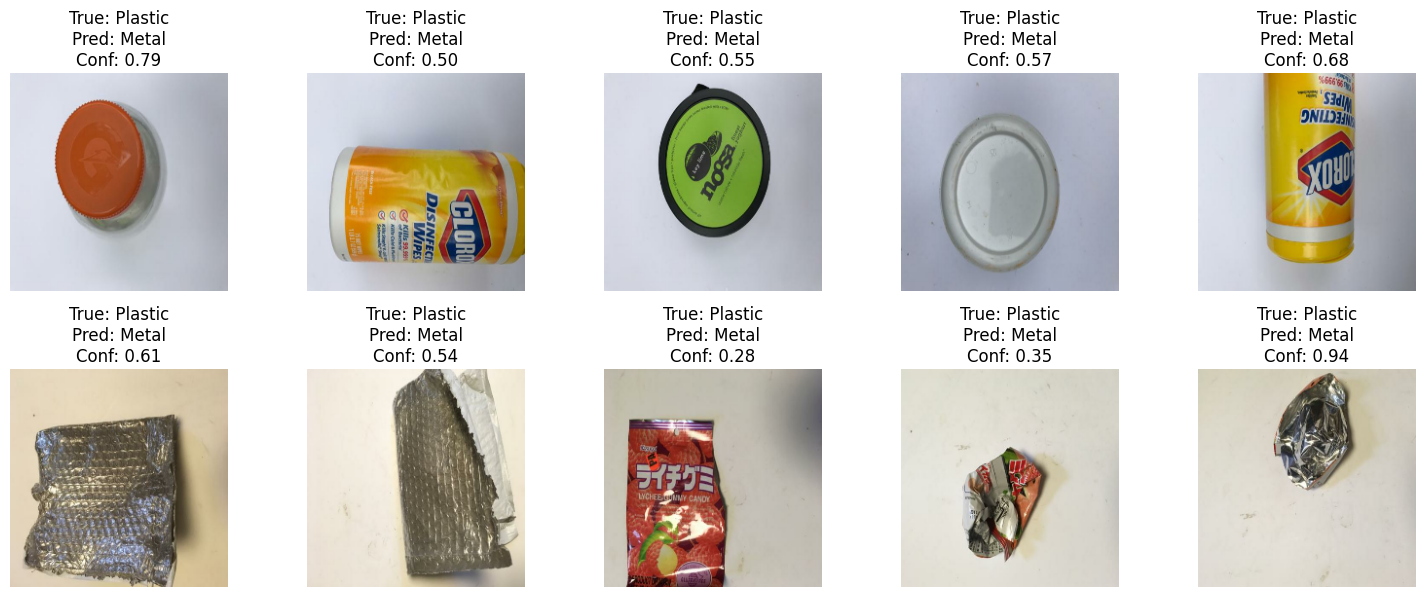

In [29]:
pair = results[
    (results["True_Name"] == "plastic") &
    (results["Pred_Name"] == "metal")
]

plt.figure(figsize=(15,12))

indices = pair.index.tolist()[:20]

for i, idx in enumerate(indices):

    plt.subplot(4,5,i+1)

    plt.imshow(validation_images[idx].astype(np.uint8))

    plt.title(
        f"True: Plastic\n"
        f"Pred: Metal\n"
        f"Conf: {results.loc[idx,'Confidence']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

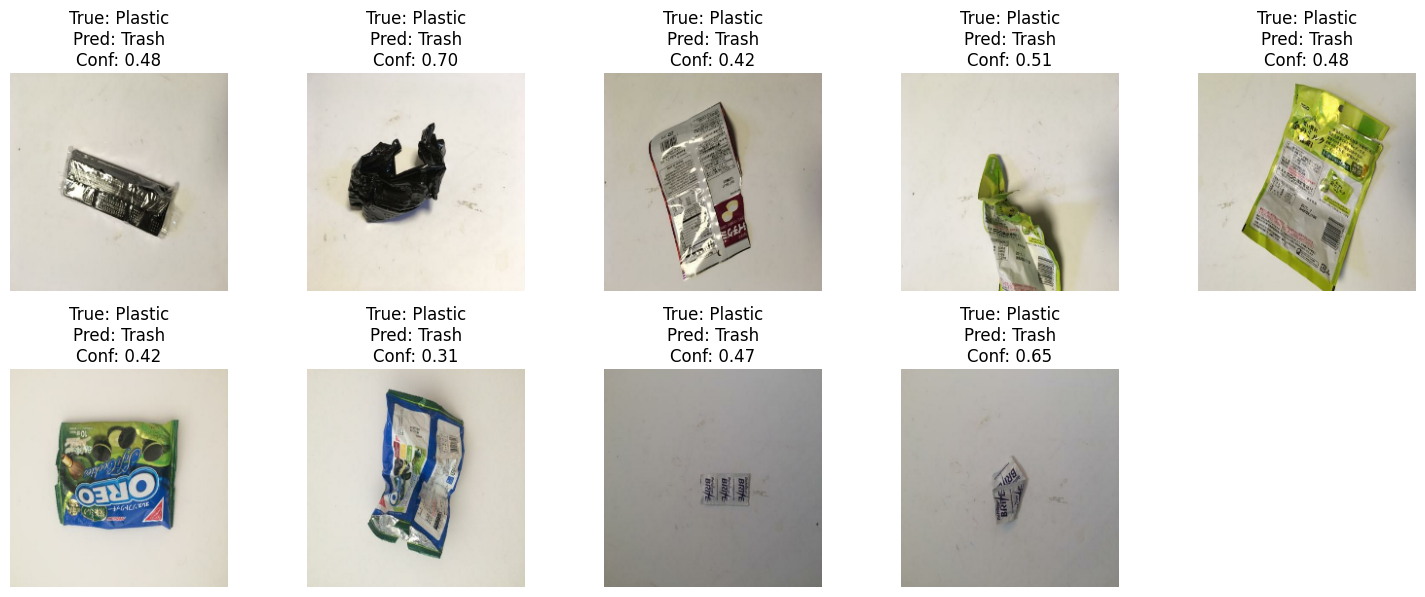

In [30]:
pair = results[
    (results["True_Name"] == "plastic") &
    (results["Pred_Name"] == "trash")
]

plt.figure(figsize=(15,12))

indices = pair.index.tolist()[:20]

for i, idx in enumerate(indices):

    plt.subplot(4,5,i+1)

    plt.imshow(validation_images[idx].astype(np.uint8))

    plt.title(
        f"True: Plastic\n"
        f"Pred: Trash\n"
        f"Conf: {results.loc[idx,'Confidence']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
for layer in reversed(model.layers):
    if len(layer.output.shape) == 4:
        last_conv_layer = layer.name
        break

print("Last Convolution Layer:", last_conv_layer)

Last Convolution Layer: efficientnetb0


In [39]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0)/tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [40]:
def show_gradcam(index):

    img = validation_images[index].astype("uint8")

    img_array = np.expand_dims(img, axis=0)

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer
    )

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

# Conclusion

In this notebook, a detailed error analysis was performed on the fine-tuned EfficientNetB0 model using the TrashNet dataset. The confusion matrix and classification report showed that the model achieved good performance across all six waste categories while revealing a few challenging class combinations.

The most common confusion pairs were Plastic → Glass, Plastic → Metal, and Plastic → Trash. These misclassifications mainly occurred because of similarities in object appearance, transparency, reflective surfaces, and damaged or irregular waste items.

By examining the misclassified images and using Grad-CAM on representative samples, it was observed that the model generally focused on the waste object itself. This analysis provided valuable insight into the strengths and limitations of the model and highlighted possible future improvements such as stronger data augmentation, improved image quality, and a larger training dataset.

Overall, this notebook demonstrates the importance of error analysis in understanding model behaviour and improving the reliability of deep learning models for real-world waste classification.